In [167]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import math
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn import datasets
from sklearn.metrics import mean_squared_error, r2_score    
from sklearn.model_selection import train_test_split


In [168]:
diabetes = datasets.load_diabetes()
data=pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
data['target']=diabetes.target
print(data.head(5))

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


C:\Users\missy\AppData\Local\Temp\ipykernel_31192\2065358206.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data['target'], palette="Set2", showmeans=True)


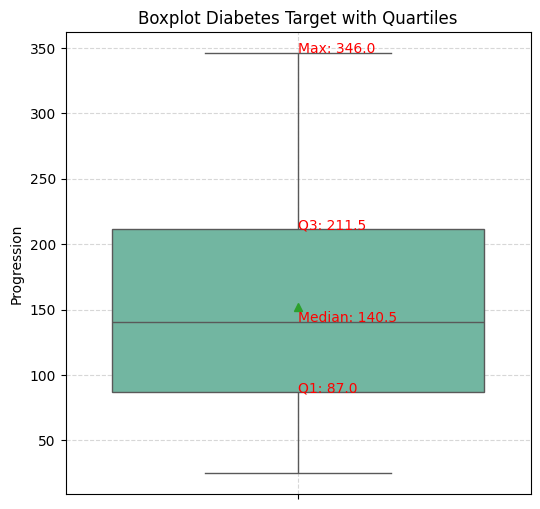

In [169]:
plt.figure(figsize=(6,6))

# Vẽ boxplot bình thường
sns.boxplot(y=data['target'], palette="Set2", showmeans=True)

# Tính các thống kê
q1 = np.percentile(data['target'], 25)
q2 = np.percentile(data['target'], 50)  # median
q3 = np.percentile(data['target'], 75)
q4 = np.percentile(data['target'], 100) # max

# Lấy trục hiện tại
ax = plt.gca()

# Annotate các giá trị
for q, label in zip([q1, q2, q3, q4], ['Q1', 'Median', 'Q3', 'Max']):
    ax.text(0, q, f'{label}: {q:.1f}', color='red', fontsize=10)

plt.title("Boxplot Diabetes Target with Quartiles")
plt.ylabel("Progression")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [170]:
model=LinearRegression()
x=data.drop('target',axis=1)
y=data['target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)   
print("R2 Score:",int(r2*100),"%")
print("Mean Squared Error:",int(mse))

R2 Score: 45 %
Mean Squared Error: 2900


Best R2 Score: 0.47 at Alpha = 2.2


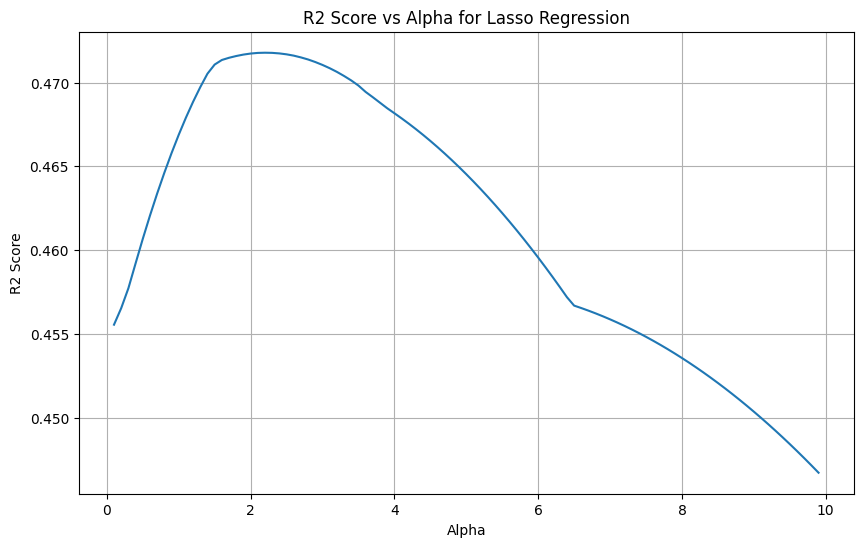

Best Mean Squared Error: 2799 at Alpha = 2.2


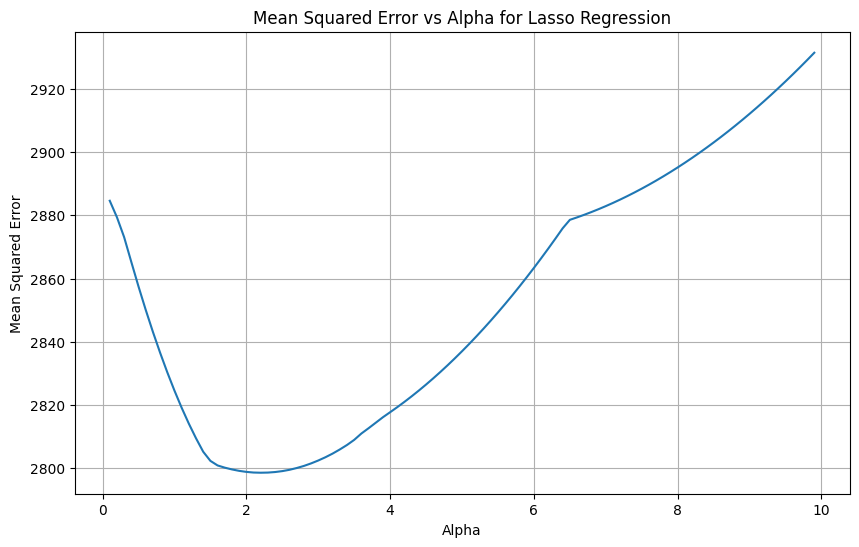

In [171]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
scaler=StandardScaler()
x=data.drop('target',axis=1)
y=data['target']
arr=[]
arrloss=[]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
alphas=np.arange(0.1,10,0.1)
for i in alphas:
    model=Lasso(alpha=i)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    r2=r2_score(y_test,y_pred)
    loss=mean_squared_error(y_test,y_pred)
    arr.append(r2)
    arrloss.append(loss)
    
max_r2=max(arr)
r2_index=arr.index(max_r2)
print("Best R2 Score:", f"{max_r2:0.2f}", "at Alpha =", alphas[r2_index])
plt.figure(figsize=(10,6))
sns.lineplot(x=alphas,y=arr)
plt.xlabel('Alpha')
plt.ylabel('R2 Score')
plt.title('R2 Score vs Alpha for Lasso Regression')
plt.grid(True)
plt.show()

min_loss=min(arrloss)
loss_index=arrloss.index(min_loss)
print("Best Mean Squared Error:", f"{min_loss:0.0f}", "at Alpha =", alphas[loss_index])
plt.figure(figsize=(10,6))
sns.lineplot(x=alphas,y=arrloss)
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Mean Squared Error vs Alpha for Lasso Regression')
plt.grid(True)
plt.show()

R2 Score: 47 %
Mean Squared Error: 2798


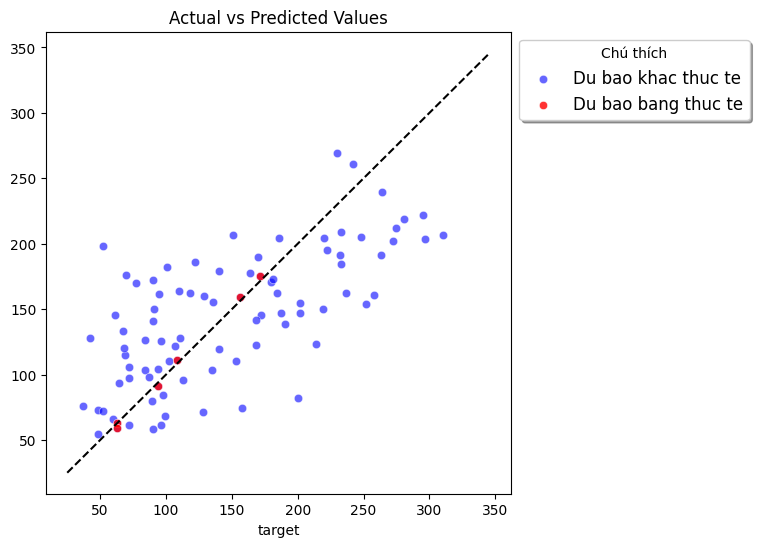

In [172]:
model=Lasso(alpha=list_alpha[r2_index])
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
print("R2 Score:",int(r2*100),"%")
print("Mean Squared Error:",int(mse))
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6, label='Du bao khac thuc te')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')  # Line y=x
plt.title("Actual vs Predicted Values")
mask = np.isclose(y_test, y_pred, atol=6) 
y_test_equal = y_test[mask]     
y_pred_equal = y_pred[mask]
sns.scatterplot(x=y_test_equal, y=y_pred_equal, color='red', alpha=0.8, label='Du bao bang thuc te')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Chú thích", shadow=True, fontsize='large')
plt.show()

Best R2 Score: 0.46 at Alpha = 68.1


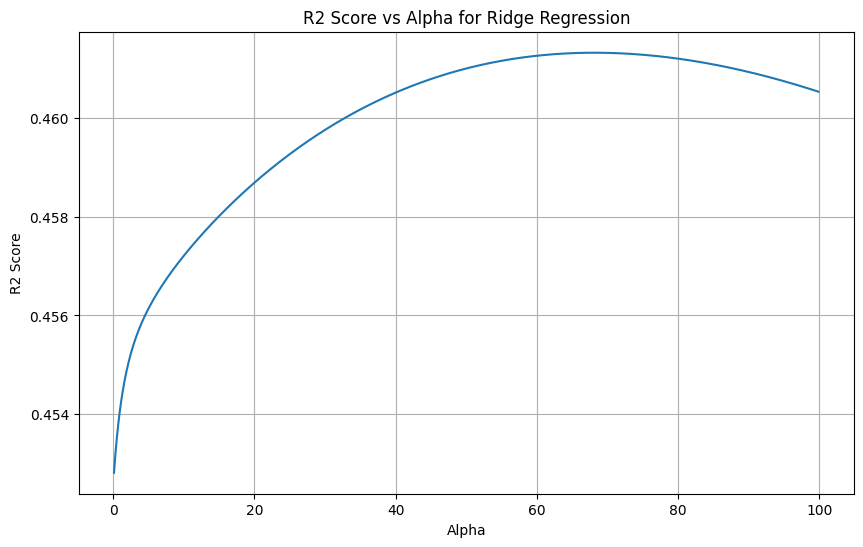

Best Mean Squared Error: 2854 at Alpha = 68.1


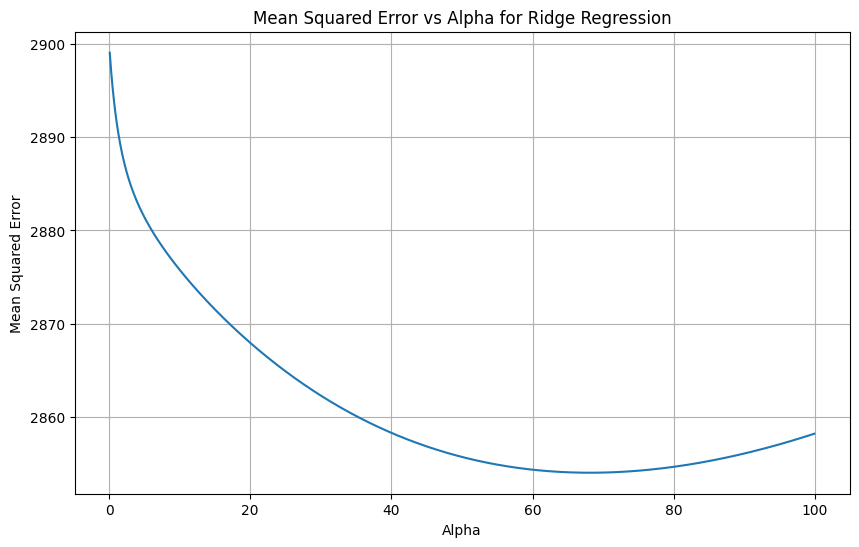

In [173]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
scaler=StandardScaler()
x=data.drop('target',axis=1)
y=data['target']
arr=[]
arrloss=[]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
list_alpha=np.arange(0.1,100,0.1)
for i in list_alpha:
    model=Ridge(alpha=i)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    r2=r2_score(y_test,y_pred)
    loss=mean_squared_error(y_test,y_pred)
    arr.append(r2)
    arrloss.append(loss)
max_r2=max(arr)
r2_index=arr.index(max_r2)
print("Best R2 Score:", f"{max_r2:0.2f}", "at Alpha =", list_alpha[r2_index])   
plt.figure(figsize=(10,6))
sns.lineplot(x=list_alpha,y=arr)
plt.xlabel('Alpha')
plt.ylabel('R2 Score')
plt.title('R2 Score vs Alpha for Ridge Regression')
plt.grid(True)
plt.show()

min_loss=min(arrloss)
loss_index=arrloss.index(min_loss)
print("Best Mean Squared Error:", f"{min_loss:0.0f}" , "at Alpha =", list_alpha[loss_index])
plt.figure(figsize=(10,6))
sns.lineplot(x=list_alpha,y=arrloss)
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Mean Squared Error vs Alpha for Ridge Regression')
plt.grid(True)
plt.show()

R2 Score: 46 %
Mean Squared Error: 2854


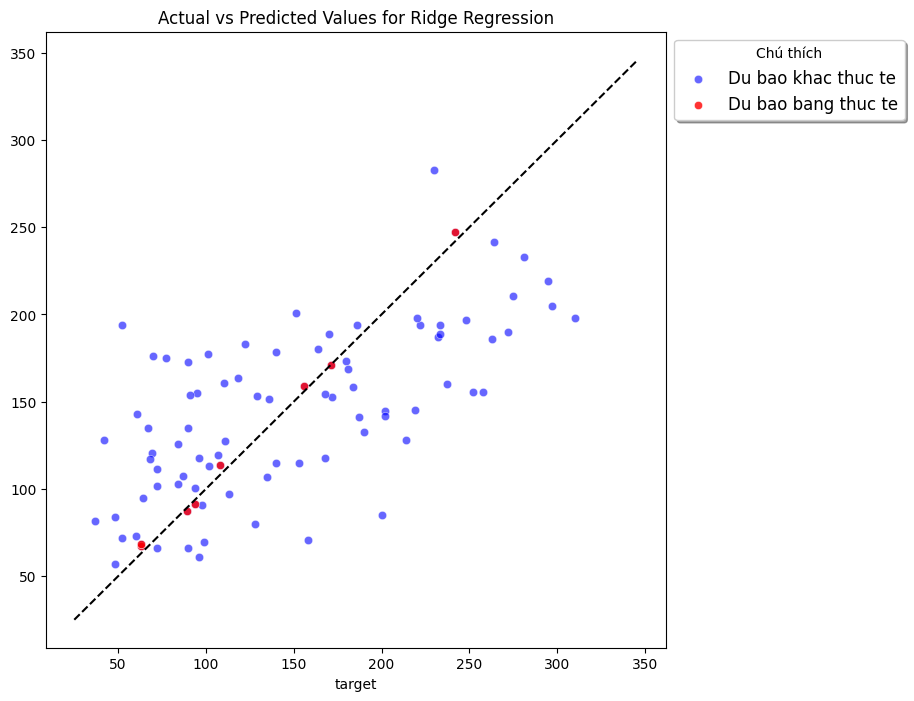

In [174]:
model=Ridge(alpha=list_alpha[r2_index])
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
print("R2 Score:",int(r2*100),"%")
print("Mean Squared Error:",int(mse))

plt.figure(figsize=(8,8))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6, label='Du bao khac thuc te')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')  # Line y=x
plt.title("Actual vs Predicted Values for Ridge Regression")
mask = np.isclose(y_test, y_pred, atol=6) 
y_test_equal = y_test[mask]     
y_pred_equal = y_pred[mask]
sns.scatterplot(x=y_test_equal, y=y_pred_equal, color='red', alpha=0.8, label='Du bao bang thuc te')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Chú thích", shadow=True, fontsize='large')
plt.show()

